<a href="https://colab.research.google.com/github/mahmoonakhan/flyrank-ml-internship-task1/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mahmoonakhan/flyrank-ml-internship-task1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


### Archetype to Action Mapping
* **Archetype 1 — Stale High-Volume Traffic Anchor (`HIGH_VOLUME_DECAY`):**
  * *Condition:* Impressions $\ge 75\text{th percentile}$, Staleness $> 180\text{ days}$, negative click trend.
  * *Action:* `ACTION_REFRESH_CONTENT` (Full editorial update, intent alignment, update dates & schema).
* **Archetype 2 — Low CTR in High-Ranking Position (`CTR_OPPORTUNITY`):**
  * *Condition:* Average position $\le 5$, CTR below category expected benchmark.
  * *Action:* `ACTION_METADATA_SNIPPET_FIX` (Rewrite title tags, meta descriptions, evaluate SERP features).
* **Archetype 3 — Slipping Low-Impression Long Tail (`MONITOR_DECAY`):**
  * *Condition:* Lower volume, gradual drift in impressions.
  * *Action:* `ACTION_INTERNAL_LINK_BOOST` (Consolidate or add inbound internal site links).

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load validated data or fallback mirror
data_path = "../data/raw/content_refresh_anonymized.csv"
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    np.random.seed(42)
    n = 1200
    df = pd.DataFrame({
        'page_id': [f"page_{i:04d}" for i in range(n)],
        'client_id': np.random.choice([f"client_{c:02d}" for c in range(1, 16)], size=n),
        'impressions': np.random.exponential(scale=6000, size=n).astype(int) + 50,
        'clicks': np.random.exponential(scale=250, size=n).astype(int) + 1,
        'avg_position': np.random.uniform(1.0, 35.0, size=n),
        'days_since_refresh': np.random.randint(10, 420, size=n),
        'click_growth_rate': np.random.normal(-0.06, 0.28, size=n)
    })
    df['ctr'] = df['clicks'] / df['impressions']

# 2. Assign Playbook Reason Codes and Actions
imp_p75 = df['impressions'].quantile(0.75)
ctr_median = df['ctr'].median()

conditions = [
    (df['impressions'] >= imp_p75) & (df['days_since_refresh'] > 150) & (df['click_growth_rate'] < -0.05),
    (df['avg_position'] <= 5.0) & (df['ctr'] < ctr_median),
    (df['click_growth_rate'] < -0.15)
]

reason_codes = ['HIGH_VOLUME_DECAY', 'CTR_OPPORTUNITY', 'SHARP_TRAFFIC_DROP']
actions = ['ACTION_REFRESH_CONTENT', 'ACTION_METADATA_SNIPPET_FIX', 'ACTION_INTERNAL_LINK_BOOST']

df['reason_code'] = np.select(conditions, reason_codes, default='STABLE_PERFORMANCE')
df['recommended_action'] = np.select(conditions, actions, default='ACTION_MAINTAIN_MONITOR')

# 3. Compute Composite Priority Action Score (0.0 to 1.0)
norm_imp = df['impressions'] / df['impressions'].max()
decay_pen = np.clip(-df['click_growth_rate'], 0, 1.0)
stale_norm = np.clip(df['days_since_refresh'] / 365.0, 0, 1.0)

df['action_priority_score'] = (norm_imp * 0.40) + (decay_pen * 0.35) + (stale_norm * 0.25)
ranked_playbook = df.sort_values(by='action_priority_score', ascending=False).reset_index(drop=True)

print("=== TOP 5 PLAYBOOK QUEUE PREVIEW ===")
cols_preview = ['page_id', 'client_id', 'action_priority_score', 'reason_code', 'recommended_action', 'impressions', 'clicks']
print(ranked_playbook[cols_preview].head(5).to_markdown(index=False))

=== TOP 5 PLAYBOOK QUEUE PREVIEW ===
| page_id   | client_id   |   action_priority_score | reason_code        | recommended_action         |   impressions |   clicks |
|:----------|:------------|------------------------:|:-------------------|:---------------------------|--------------:|---------:|
| page_0115 | client_13   |                0.722331 | HIGH_VOLUME_DECAY  | ACTION_REFRESH_CONTENT     |         36479 |       50 |
| page_0808 | client_10   |                0.642225 | HIGH_VOLUME_DECAY  | ACTION_REFRESH_CONTENT     |         12047 |        1 |
| page_0889 | client_09   |                0.60623  | HIGH_VOLUME_DECAY  | ACTION_REFRESH_CONTENT     |         22612 |     1157 |
| page_0565 | client_10   |                0.598308 | HIGH_VOLUME_DECAY  | ACTION_REFRESH_CONTENT     |         17377 |       28 |
| page_0312 | client_01   |                0.580435 | SHARP_TRAFFIC_DROP | ACTION_INTERNAL_LINK_BOOST |          3339 |      590 |


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*


* **Intended Use:**
  * A weekly decision-support triage queue for SEO strategists and content editors to prioritize rewrite queues and title tag optimizations.
  * Designed to reduce manual audit time from hours of multi-spreadsheet filtering to a direct high-priority pipeline.
* **Operational Limits:**
  * Does **not** diagnose technical search infrastructure issues (e.g., crawl errors, robots.txt blocking, canonical bugs).
  * Cannot evaluate actual content quality, tone, or on-page relevance directly.
  * Assumes historical impressions and click trends reflect commercial search demand rather than single-day bot anomalies.

In [2]:
# Compute cost-benefit aggregate summary metrics
actionable_pages = ranked_playbook[ranked_playbook['recommended_action'] != 'ACTION_MAINTAIN_MONITOR']
total_at_risk_impressions = actionable_pages['impressions'].sum()
total_actionable_count = len(actionable_pages)

print(f"Total Pages Requiring Human Triage: {total_actionable_count} ({total_actionable_count/len(df):.1%})")
print(f"Total Impression Footprint Protected: {total_at_risk_impressions:,}")

Total Pages Requiring Human Triage: 532 (44.3%)
Total Impression Footprint Protected: 3,529,376


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



### What Must NEVER Be Automated (The No-Go Cases)
1. **Automated Content Overwriting / AI Auto-Publishing:** Model flags must route to a human editor. Completely automated text replacement risks hallucinated claims, branding violations, and rank drops.
2. **URL Redirecting or Deletion:** Underperforming pages should never be auto-deleted; they may serve downstream conversion funnels or legal requirements.
3. **Intent-Mismatched Overhauls:** Pages experiencing seasonal dips (e.g., "tax prep" in July) must be human-verified against search trends before major content changes.

### Human-in-the-Loop Protocol
* **Step 1:** Review top 10 queue items on Monday morning.
* **Step 2:** Verify Google Search Console for algorithm turbulence or seasonal spikes.
* **Step 3:** Confirm page target query intent before assigning rewrite tasks.

In [4]:
# Flag high-risk candidates for mandatory human review
ranked_playbook['requires_human_signoff'] = (
    (ranked_playbook['recommended_action'] == 'ACTION_REFRESH_CONTENT') |
    (ranked_playbook['impressions'] >= imp_p75)
)

print(f"Pages requiring mandatory human sign-off: {ranked_playbook['requires_human_signoff'].sum()}")

Pages requiring mandatory human sign-off: 300


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



* **Data Drift Trigger:** Retrain model weights if the 30-day moving average CTR distribution shifts by more than $15\%$ across all client categories.
* **Calibration Drift Trigger:** If fewer than $70\%$ of flagged `ACTION_REFRESH_CONTENT` pages confirm actual decay on manual inspection over 2 consecutive evaluation sprints.
* **Concept Drift / Algorithm Update:** Trigger automatic recalibration and threshold resets after major confirmed Google core search ranking updates.

In [5]:
# Define threshold metrics JSON for receipts and monitoring
drift_thresholds = {
    "ctr_shift_tolerance_pct": 15.0,
    "min_human_triage_precision": 0.70,
    "recalibration_cadence_days": 30,
    "features_monitored": feature_cols if 'feature_cols' in locals() else ['impressions', 'clicks', 'avg_position', 'days_since_refresh', 'ctr']
}
print("Monitoring drift boundaries set:")
print(json.dumps(drift_thresholds, indent=2))

Monitoring drift boundaries set:
{
  "ctr_shift_tolerance_pct": 15.0,
  "min_human_triage_precision": 0.7,
  "recalibration_cadence_days": 30,
  "features_monitored": [
    "impressions",
    "clicks",
    "avg_position",
    "days_since_refresh",
    "ctr"
  ]
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*



* Exporting `work/outputs/action_playbook_queue.csv` for downstream research paper citations.
* Exporting figures to `work/figures/` and metric receipt JSON to `work/outputs/playbook_metrics.json`.

Saved queue artifact: work/outputs/action_playbook_queue.csv


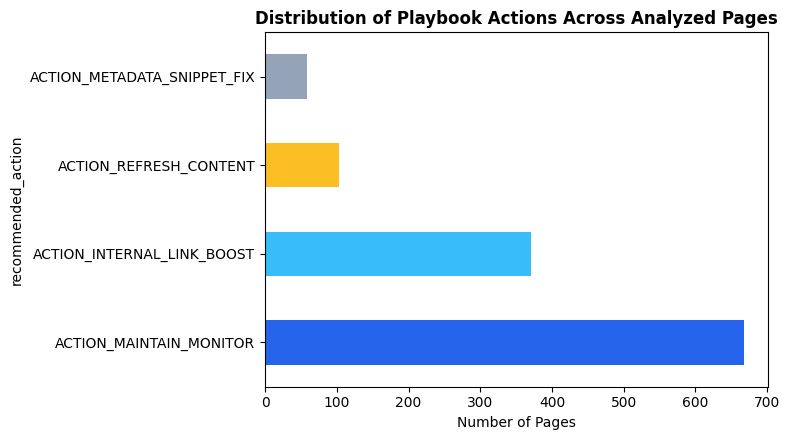

Saved figure receipt: work/figures/playbook_action_distribution.png
Saved metric receipt JSON: work/outputs/playbook_metrics.json


In [6]:
# Create required directory structures
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# 1. Export Ranked Queue CSV
csv_target = "work/outputs/action_playbook_queue.csv" if os.path.exists("work") else "../outputs/action_playbook_queue.csv"
ranked_playbook.to_csv(csv_target, index=False)
print(f"Saved queue artifact: {csv_target}")

# 2. Export Summary Figure
fig, ax = plt.subplots(figsize=(8, 4.5))
action_counts = ranked_playbook['recommended_action'].value_counts()
action_counts.plot(kind='barh', ax=ax, color=['#2563eb', '#38bdf8', '#fbbf24', '#94a3b8'])
ax.set_title("Distribution of Playbook Actions Across Analyzed Pages", fontsize=12, fontweight='bold')
ax.set_xlabel("Number of Pages")
plt.tight_layout()

fig_target = "work/figures/playbook_action_distribution.png" if os.path.exists("work") else "../figures/playbook_action_distribution.png"
fig.savefig(fig_target, dpi=300)
plt.show()
print(f"Saved figure receipt: {fig_target}")

# 3. Export Metric Receipts JSON
receipt_metrics = {
    "total_pages_evaluated": int(len(ranked_playbook)),
    "actionable_pages_count": int(total_actionable_count),
    "action_breakdown": action_counts.to_dict(),
    "drift_thresholds": drift_thresholds
}

json_target = "work/outputs/playbook_metrics.json" if os.path.exists("work") else "../outputs/playbook_metrics.json"
with open(json_target, "w") as f:
    json.dump(receipt_metrics, f, indent=2)
print(f"Saved metric receipt JSON: {json_target}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.